### IPL 2022 Capstone Project

**The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.**

**These are some of the important columns that we'll focus on for meaningful insights in this project.**

**column names: Variable Type**
* date : string  
* venue : string  
* stage : string  
* team1 : string  
* team2 : string  
* toss_winner : string  
* toss_decision : string  
* first_ings_score : integer  
* second_ings_score : integer  
* match_winner : string  
* won_by : string  
* margin : integer  
* player_of_the_match : string  
* top_scorer : string  
* highscore : integer  
* best_bowling : string  
* best_bowling_fgure : string  
gure : string  


### Loading the Libraries and Dataset

In [13]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings("ignore")

df = pd.read_csv( 'IPL.csv')

df.head()



,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


### Basic Information

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

Check the size of rows and columns of the dataset

In [15]:
print(f"your rows are {df.shape[0]} and your columns are {df.shape[1]}")

your rows are 74 and your columns are 20


Now let's see how many columns have null values in total.

In [16]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

**Now, Here comes some Basic Questions**

1. Which team won the most matches?

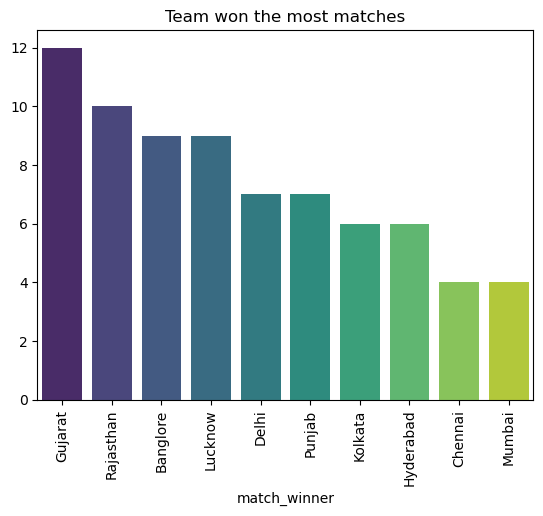

In [24]:

counts=df['match_winner'].value_counts()
sns.barplot(x= counts.index,y=counts.values,palette='viridis')
plt.xticks(rotation=90)
plt.title("Team won the most matches")
plt.show()


2. Toss Decision Trends

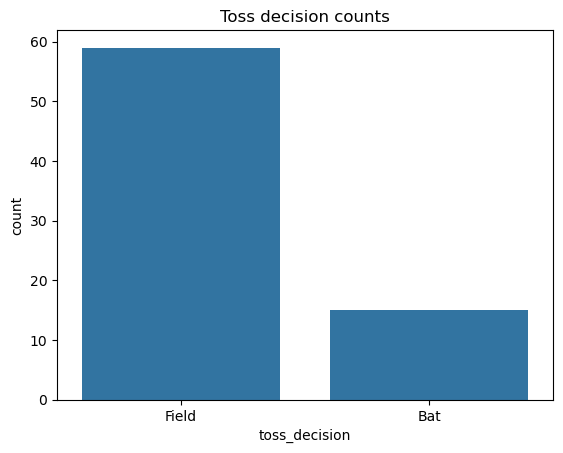

In [23]:
data=df['toss_decision'].value_counts()
sns.countplot(x=df['toss_decision'])
plt.title("Toss decision counts")
plt.show()

3. Toss Winner vs Match Winner

In [42]:
same_winner=df[df['toss_winner']==df['match_winner']]["match_id"].count()
percentage=(same_winner*100)/df.shape[0]
percent=percentage.round(2)
print('The percentage of same winner is equal to ',percent)

The percentage of same winner is equal to  48.65


4. How do teams win? (Runs vs Wickets)

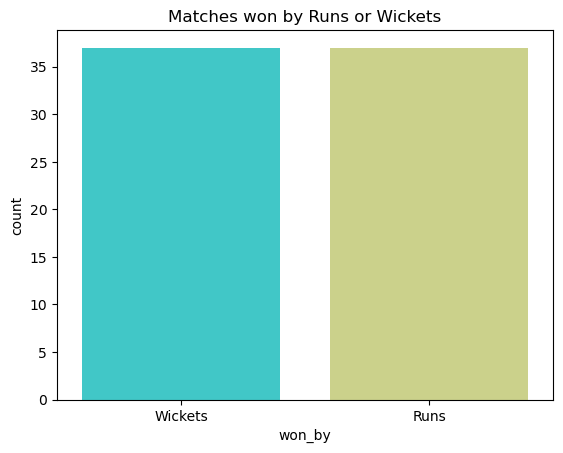

In [45]:
sns.countplot(x=df['won_by'],palette="rainbow")
plt.title("Matches won by Runs or Wickets")
plt.show()


###  Key Player Performances

1 Most "Player of the Match" Awards

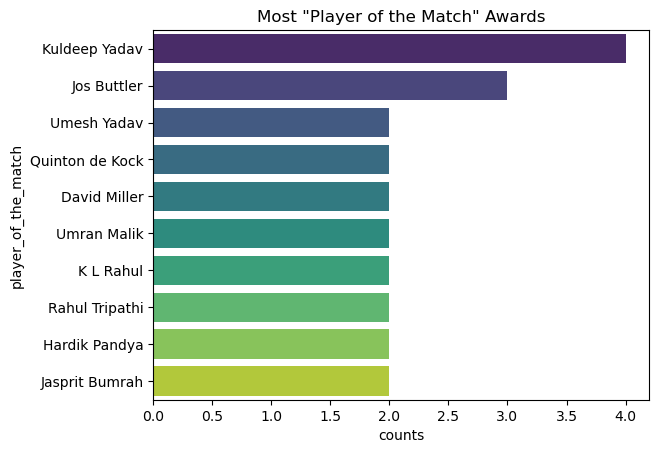

In [63]:
player=df['player_of_the_match'].value_counts().head(10)
sns.barplot(x=player.values,y=player.index,palette='viridis')
plt.title('Most "Player of the Match" Awards')
plt.xlabel('counts')
plt.show()


2 Top Scorers

Text(0.5, 1.0, 'Top 10 Scorer')

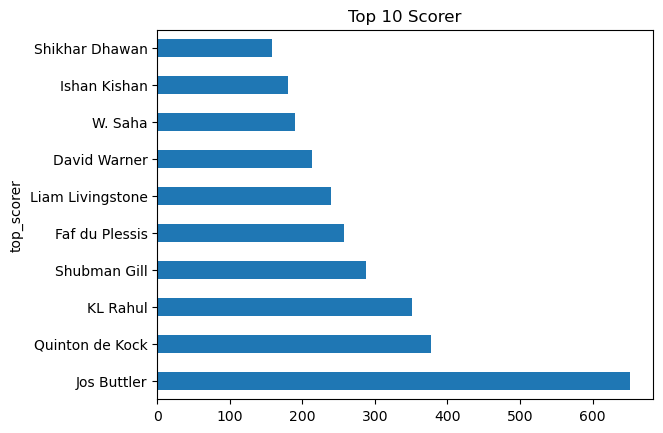

In [68]:



top_scorer=df.groupby("top_scorer")['highscore'].sum().sort_values(ascending=False).head(10)
top_scorer.plot(kind='barh')
plt.title("Top 10 Scorer")


10 Best Bowling Figures

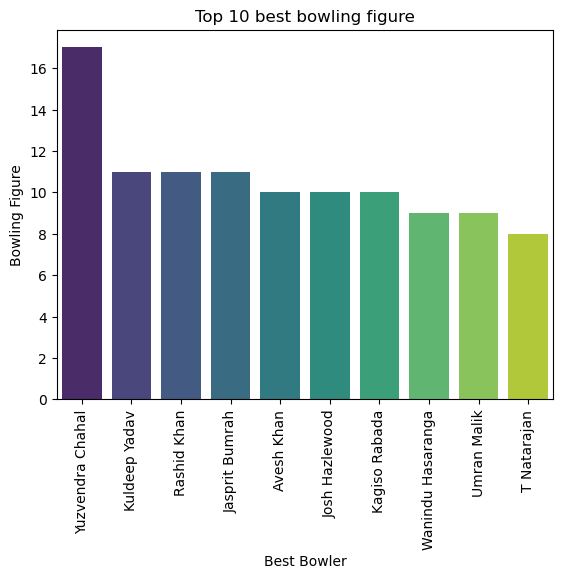

In [80]:
df['high_wicket']=df["best_bowling_figure"].apply(lambda x: x.split("--")[0])
df['high_wicket']=df['high_wicket'].astype(int) 
best_figure=df.groupby('best_bowling')['high_wicket'].sum().sort_values(ascending=False).head(10)
sns.barplot(x= best_figure.index,y=best_figure.values,palette='viridis')
plt.xticks(rotation=90)
plt.title("Top 10 best bowling figure")
plt.xlabel("Best Bowler")
plt.ylabel('Bowling Figure')
plt.show()



What is the distribution of scores in the first innings? Are most scores clustered around a certain range?

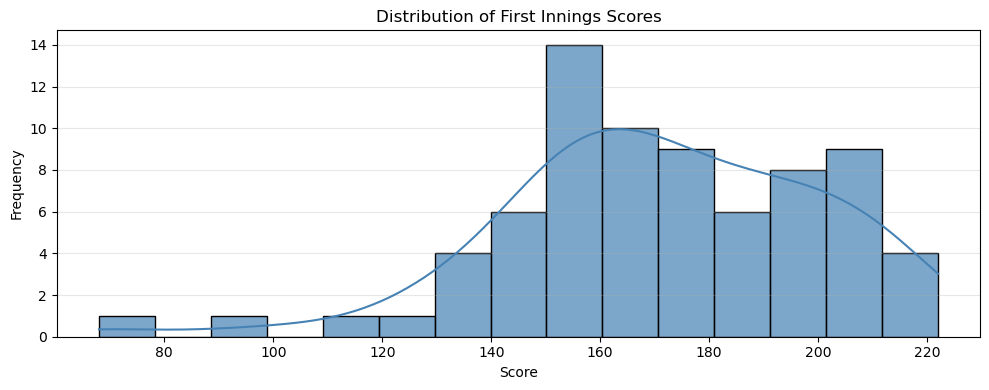

In [108]:
plt.figure(figsize=(10, 4))
sns.histplot(df['first_ings_score'], kde=True, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of First Innings Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Insights

# Most scores lie between 150 and 200
# Peak around - 155 to 170
# Left(Neagtive) Skewed distribution 
# Possible outlier because score around 70-100 apper far away 

Is there a relationship between first innings score and second innings score? Do high-scoring teams on batting first score high on batting second?


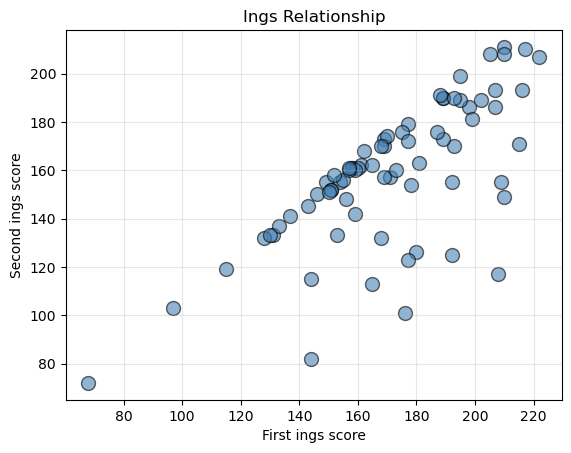

Correlation: 0.704


In [118]:
plt.scatter(df['first_ings_score'], df['second_ings_score'], 
           alpha=0.6, s=100, color='steelblue', edgecolors='black')
plt.title('Ings Relationship')
plt.xlabel("First ings score")
plt.ylabel("Second ings score")
plt.grid(alpha=0.3)
plt.show()
correlation = df['first_ings_score'].corr(df['second_ings_score'])
print(f"Correlation: {correlation:.3f}")

In [ ]:
#Insights
# As we can see the graphs grows up when both the values are increasing
# so there is positive relationship/correaltion
# no negative realtionship

Which teams typically win after batting second(chasing)? Show with colors.

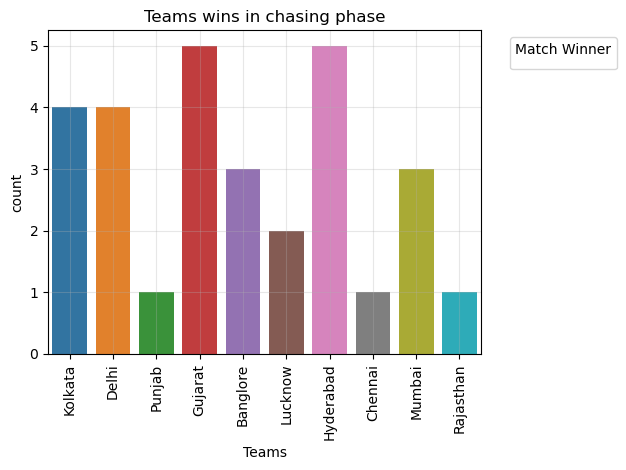

In [ ]:

chasing=df[(df["toss_decision"]=='Field') & (df['toss_winner']== df['match_winner'])]
sns.countplot(data=chasing , x='match_winner',hue='match_winner')
plt.xticks(rotation=90)
plt.title('Teams wins in chasing phase')
# plt.legend(title='Match Winner', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(alpha=0.3)
plt.xlabel('Teams')
plt.tight_layout()
plt.show()


Does the toss decision (Bat/Field) affect the score? Compare distributions. ( here the data is categorical and numerical so we use box plots)

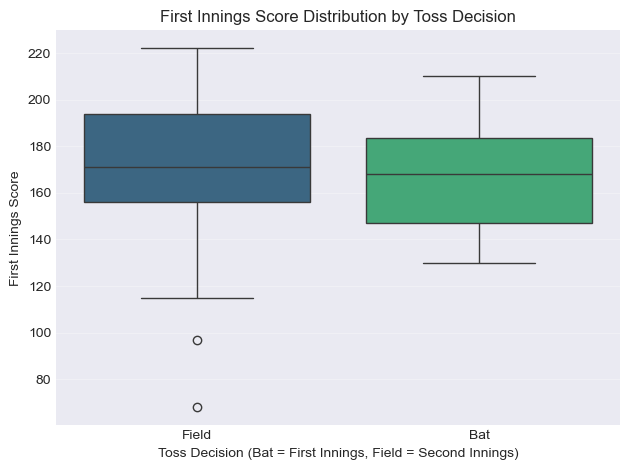

In [146]:
sns.boxplot(data=df,x='toss_decision',y='first_ings_score', palette='viridis')
plt.title('First Innings Score Distribution by Toss Decision')
plt.xlabel('Toss Decision (Bat = First Innings, Field = Second Innings)')
plt.ylabel('First Innings Score')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

# Insights
# The team choosing the field have slighlty higher score.
# There is outliers present in the field category
# The difference in score is not majorly high, there is a small difference in score 

Compare distributions of first innings score and second innings score side-by-side.


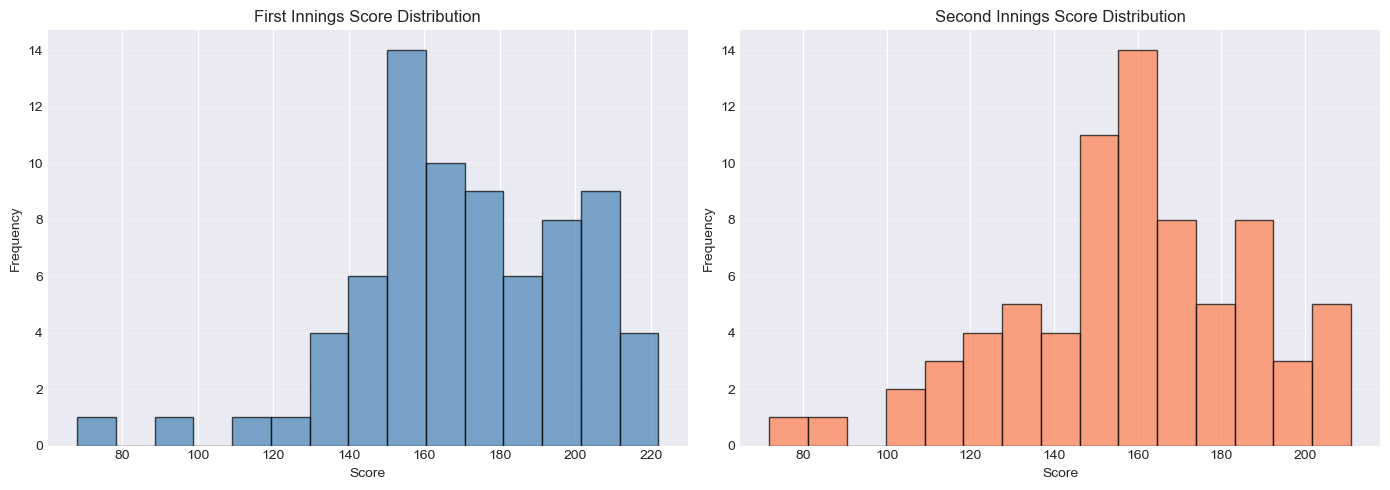

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# First Innings
axes[0].hist(df['first_ings_score'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('First Innings Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

# Second Innings
axes[1].hist(df['second_ings_score'], bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Second Innings Score Distribution')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

See relationships between ALL numerical variables at once.

<Figure size 1000x800 with 0 Axes>

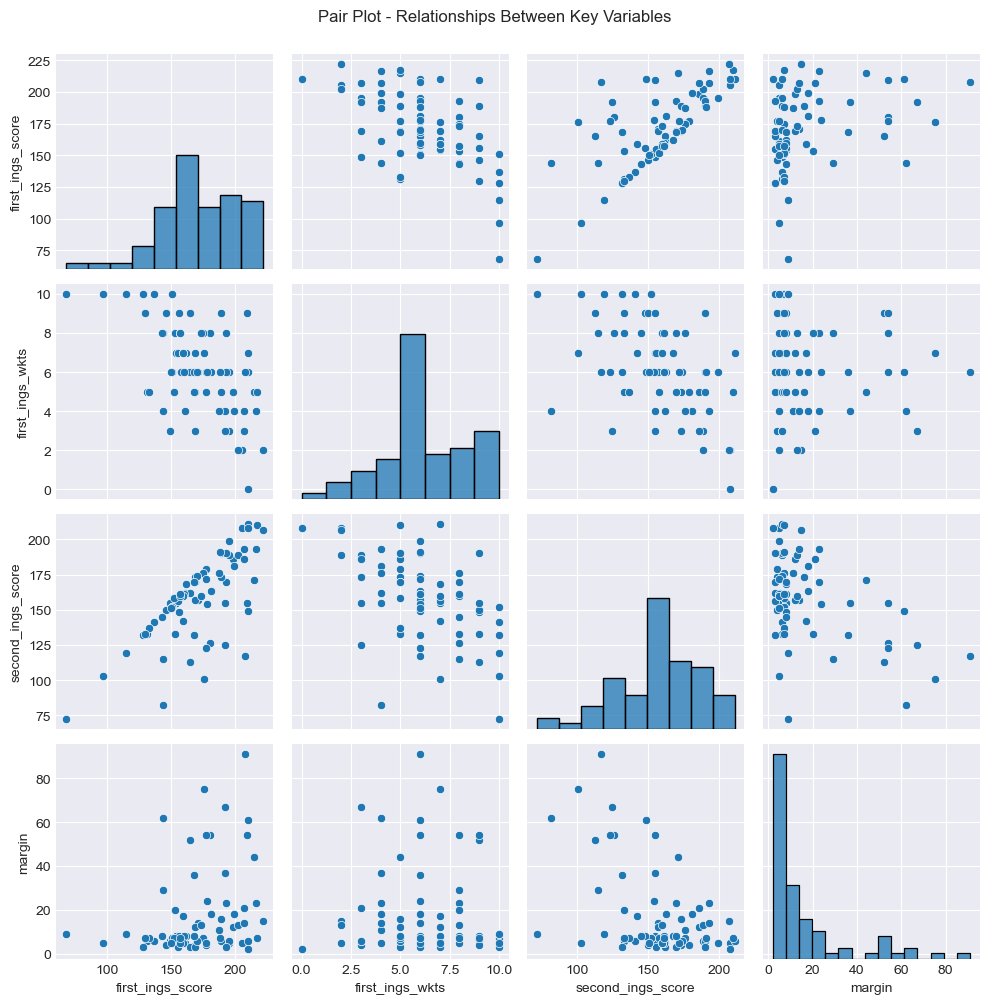

In [154]:
plot_cols = ['first_ings_score', 'first_ings_wkts', 'second_ings_score', 'margin']
data_subsets = df[plot_cols]
plt.figure(figsize=(10, 8))
sns.pairplot(data_subsets, )
plt.suptitle('Pair Plot - Relationships Between Key Variables', y=1.00)
plt.tight_layout()
plt.show()

###  Venue Analysis

Most Matches Played by Venue

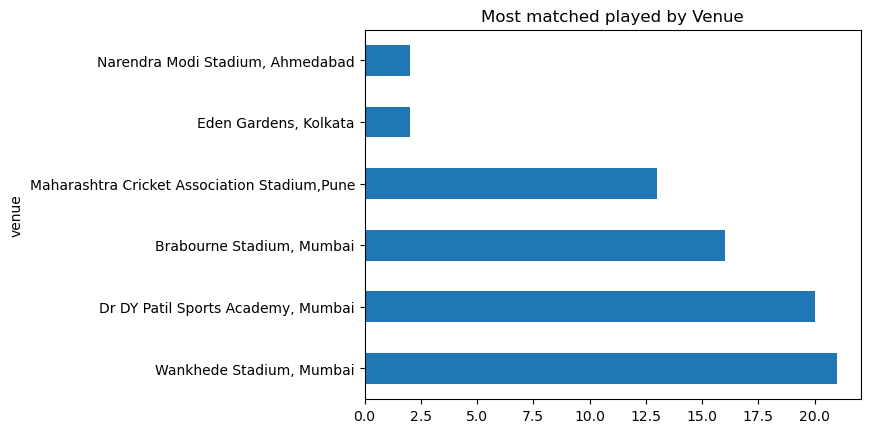

In [88]:

venue=df['venue'].value_counts()
venue.plot(kind='barh')
plt.title('Most matched played by Venue')
plt.show()

### Custom Questions & Insights
Q1: Who won the highest margin by runs?

In [92]:
df[df['won_by']=="Runs"].sort_values(by='margin',ascending=False)[['match_winner', 'margin']].head(1)

,match_winner,margin
54,Chennai,91


Q2: Which player had the highest individual score?

In [97]:
df[df['highscore']==df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


Q3: Which bowler had the best bowling figures?

In [ ]:

df[df['high_wicket']==df['high_wicket'].max()][['best_bowling','best_bowling_figure','high_wicket']]

,best_bowling,best_bowling_figure,high_wicket
29,Yuzvendra Chahal,5--40,5
39,Umran Malik,5--25,5
53,Wanindu Hasaranga,5--18,5
55,Jasprit Bumrah,5--10,5


# Good Work